# 1 - biliotecas 

In [1]:
import numpy as np
import torch
from torch import nn
from tqdm import tqdm
from torchvision import transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(0)

# 2 - paths 

In [2]:
label_path = "Sismica/train/Output/seismic_TRAIN_LABEL_crops.npy"
seismic_path = "Sismica/train/Input/seismic_TRAIN_IMAGE_crops.npy"
seismic_test = "Sismica/test/Input/seismic_TEST_IMAGE_crops_S.npy"

In [3]:
seismic = np.load(seismic_path)
label = np.load(label_path)
test = np.load(seismic_path)

# Analise do vetor em numpy da sismica 

In [4]:
seismic

array([[[ 314.90967 ,  237.88016 ,  161.49757 , ..., -502.72876 ,
         -521.31274 , -502.98462 ],
        [-255.15192 , -316.2876  , -383.25708 , ..., -294.50537 ,
         -379.58887 , -437.45654 ],
        [-576.45605 , -564.44434 , -556.95557 , ...,  141.2532  ,
           47.26915 ,  -46.431366],
        ...,
        [ 454.85132 ,  651.3489  ,  719.0576  , ...,  170.58904 ,
          316.43066 ,  364.12402 ],
        [ 604.2803  ,  790.7825  ,  909.55347 , ...,   19.218903,
           44.073532,   34.23491 ],
        [ 517.24243 ,  574.48145 ,  688.4656  , ...,  -99.948425,
         -180.76651 , -234.48941 ]],

       [[-121.20087 , -162.96156 , -207.82088 , ...,  210.46043 ,
          190.47864 ,  154.83926 ],
        [ -38.64006 ,  -93.16231 , -133.7568  , ..., -130.19002 ,
         -151.10216 , -217.035   ],
        [ 232.18768 ,  170.1328  ,  126.59544 , ..., -388.52344 ,
         -382.00977 , -420.73267 ],
        ...,
        [ -73.978455,  -16.672379,   -2.820404, ..., -

# analise para identificar a classe desbalanceada 

In [5]:
label_volume = label
# Conta a ocorrência de cada classe
vals, counts = np.unique(label_volume, return_counts=True)

# Exibe proporções
total = counts.sum()
for v, c in zip(vals, counts):
    pct = (c / total) * 100
    print(f"Classe {v}: {c} voxels ({pct:.3f}%)")

Classe 0: 143523922 voxels (15.191%)
Classe 1: 403713159 voxels (42.729%)
Classe 2: 38467482 voxels (4.071%)
Classe 3: 272351205 voxels (28.826%)
Classe 4: 6613207 voxels (0.700%)
Classe 5: 80145105 voxels (8.483%)


# analise dos dados da sismica

In [6]:

print("shape:", seismic.shape)
print("dtype:", seismic.dtype)
print("min/max (ignorando NaN):", np.nanmin(seismic), np.nanmax(seismic))
print("NaNs:", np.isnan(seismic).sum())

shape: (18830, 224, 224)
dtype: float32
min/max (ignorando NaN): -5195.5234 5151.7188
NaNs: 0


In [7]:
print("ndim  :", seismic.ndim)      # nº de dimensões
print("shape :", seismic.shape)     # formato
print("size  :", seismic.size)      # qtde de elementos
print("dtype :", seismic.dtype)     # tipo
print("min   :", seismic.min())
print("max   :", seismic.max())
print("média :", seismic.mean())
print("std   :", seismic.std())
print("únicos:", np.unique(seismic))


ndim  : 3
shape : (18830, 224, 224)
size  : 944814080
dtype : float32
min   : -5195.5234
max   : 5151.7188
média : 0.60940266
std   : 384.3913
únicos: [-5195.5234 -5184.1055 -5184.0664 ...  5124.6484  5137.1797  5151.7188]


# slices 

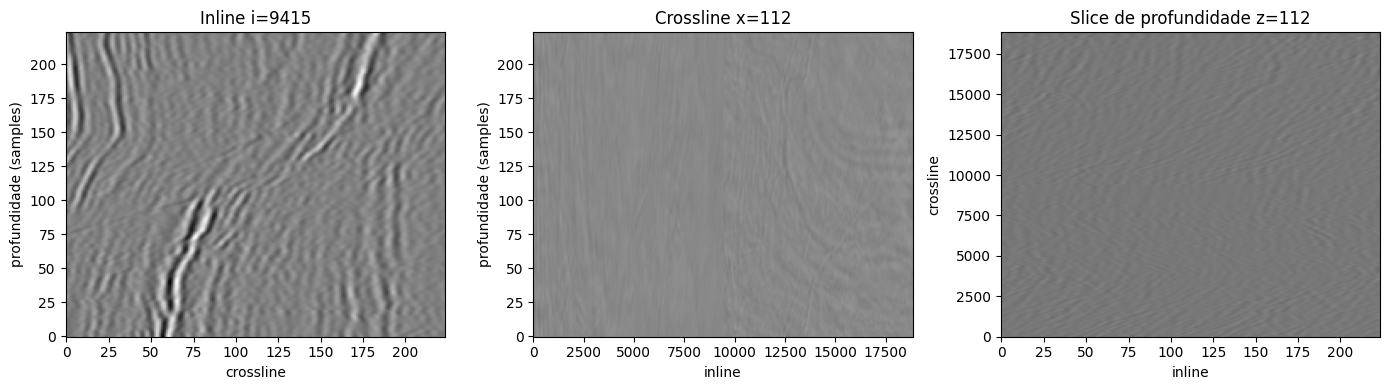

In [8]:

plt.figure(figsize=(14,4))


vol = seismic             # vira ndarray
vol = np.asarray(vol, dtype=np.float32)
vol = np.nan_to_num(vol)   
I, X, Z = vol.shape
i0 = I // 2   # inline central
x0 = X // 2   # crossline central
z0 = Z // 2   # slice de profundidade central

# INLINE: fixa inline i0 → matriz (X, Z)
plt.subplot(1,3,1)
plt.imshow(vol[i0, :, :].T, cmap="gray", aspect="auto", origin="lower")
plt.title(f"Inline i={i0}")
plt.xlabel("crossline"); plt.ylabel("profundidade (samples)")

# CROSSLINE: fixa crossline x0 → matriz (I, Z)
plt.subplot(1,3,2)
plt.imshow(vol[:, x0, :].T, cmap="gray", aspect="auto", origin="lower")
plt.title(f"Crossline x={x0}")
plt.xlabel("inline"); plt.ylabel("profundidade (samples)")

# TIME/DEPTH SLICE: fixa profundidade z0 → matriz (I, X)
plt.subplot(1,3,3)
plt.imshow(vol[:, :, z0], cmap="gray", aspect="auto", origin="lower")
plt.title(f"Slice de profundidade z={z0}")
plt.xlabel("inline"); plt.ylabel("crossline")

plt.tight_layout(); plt.show()


# Label

In [9]:

print("ndim  :", label.ndim)      # nº de dimensões
print("shape :", label.shape)     # formato
print("size  :", label.size)      # qtde de elementos
print("dtype :", label.dtype)     # tipo
print("min   :", label.min())
print("max   :", label.max())
print("média :", label.mean())
print("std   :", label.std())
print("únicos:", np.unique(label))


ndim  : 3
shape : (18830, 224, 224)
size  : 944814080
dtype : int32
min   : 0
max   : 5
média : 1.8256291131901845
std   : 1.443679548838823
únicos: [0 1 2 3 4 5]


# analise da label

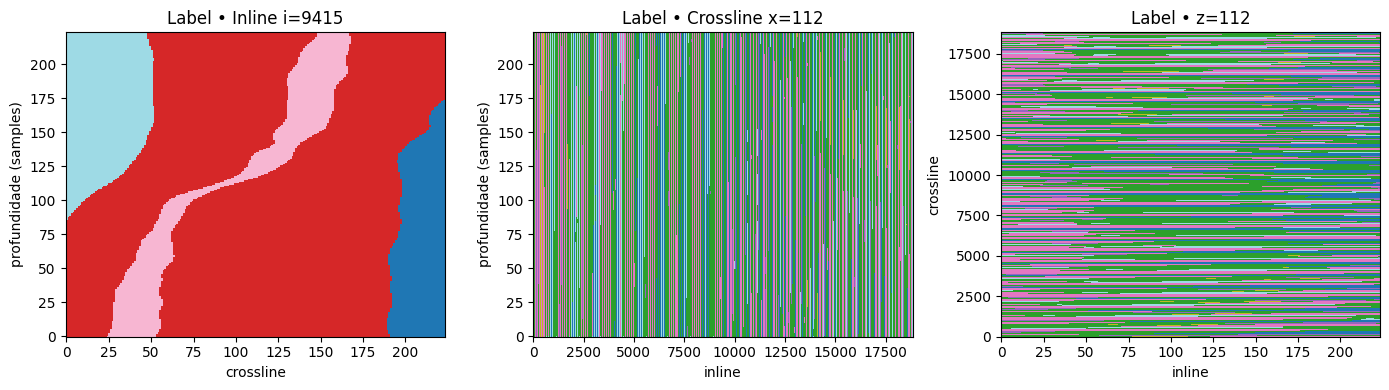

In [10]:
vol = label              # vira ndarray
vol = np.asarray(vol, dtype=np.float32)
vol = np.nan_to_num(vol)

# LABEL — Bloco 2 — índices centrais
I, X, Z = vol.shape
i0 = I // 2
x0 = X // 2
z0 = Z // 2

# LABEL — Bloco 3 — figura base
plt.figure(figsize=(14, 4))

# LABEL — Bloco 4 — INLINE
plt.subplot(1, 3, 1)
plt.imshow(vol[i0, :, :].T, cmap="tab20", origin="lower", aspect="auto", interpolation="nearest")
plt.title(f"Label • Inline i={i0}")
plt.xlabel("crossline"); plt.ylabel("profundidade (samples)")

# LABEL — Bloco 5 — CROSSLINE
plt.subplot(1, 3, 2)
plt.imshow(vol[:, x0, :].T, cmap="tab20", origin="lower", aspect="auto", interpolation="nearest")
plt.title(f"Label • Crossline x={x0}")
plt.xlabel("inline"); plt.ylabel("profundidade (samples)")

# LABEL — Bloco 6 — SLICE de profundidade
plt.subplot(1, 3, 3)
plt.imshow(vol[:, :, z0], cmap="tab20", origin="lower", aspect="auto", interpolation="nearest")
plt.title(f"Label • z={z0}")
plt.xlabel("inline"); plt.ylabel("crossline")

# LABEL — Bloco 7 — layout e render
plt.tight_layout()
plt.show()


# analise do teste 

In [11]:
print("ndim  :", test.ndim)      # nº de dimensões
print("shape :", test.shape)     # formato
print("size  :", test.size)      # qtde de elementos
print("dtype :", test.dtype)     # tipo
print("min   :", test.min())
print("max   :", test.max())
print("média :", test.mean())
print("std   :", test.std())
print("únicos:", np.unique(test))


ndim  : 3
shape : (18830, 224, 224)
size  : 944814080
dtype : float32
min   : -5195.5234
max   : 5151.7188
média : 0.60940266
std   : 384.3913
únicos: [-5195.5234 -5184.1055 -5184.0664 ...  5124.6484  5137.1797  5151.7188]


# slices do arquivo teste - tentendo como o arquivo de teste esta estruturado 

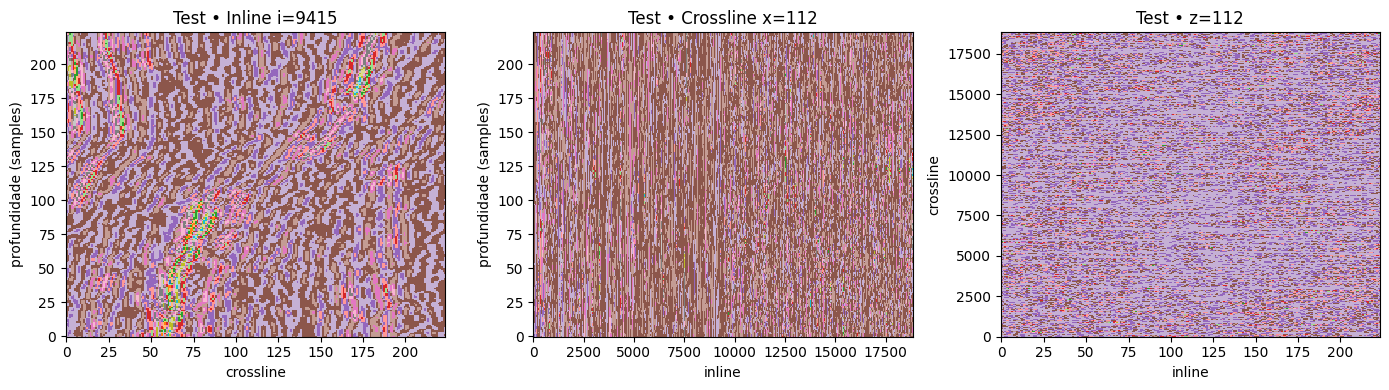

In [12]:
vol = test                # vira ndarray
vol = np.asarray(vol, dtype=np.float32)
vol = np.nan_to_num(vol)
# TEST — Bloco 2 — índices centrais
I, X, Z = vol.shape
i0 = I // 2
x0 = X // 2
z0 = Z // 2

# TEST — Bloco 3 — figura base
plt.figure(figsize=(14, 4))

# TEST — Bloco 4 — INLINE
plt.subplot(1, 3, 1)
plt.imshow(vol[i0, :, :].T, cmap="tab20", origin="lower", aspect="auto", interpolation="nearest")
plt.title(f"Test • Inline i={i0}")
plt.xlabel("crossline"); plt.ylabel("profundidade (samples)")

# TEST — Bloco 5 — CROSSLINE
plt.subplot(1, 3, 2)
plt.imshow(vol[:, x0, :].T, cmap="tab20", origin="lower", aspect="auto", interpolation="nearest")
plt.title(f"Test • Crossline x={x0}")
plt.xlabel("inline"); plt.ylabel("profundidade (samples)")

# TEST — Bloco 5 — CROSSLINE
plt.subplot(1, 3, 2)
plt.imshow(vol[:, x0, :].T, cmap="tab20", origin="lower", aspect="auto", interpolation="nearest")
plt.title(f"Test • Crossline x={x0}")
plt.xlabel("inline"); plt.ylabel("profundidade (samples)")

# TEST — Bloco 6 — SLICE de profundidade
plt.subplot(1, 3, 3)
plt.imshow(vol[:, :, z0], cmap="tab20", origin="lower", aspect="auto", interpolation="nearest")
plt.title(f"Test • z={z0}")
plt.xlabel("inline"); plt.ylabel("crossline")

# TEST — Bloco 7 — layout e render
plt.tight_layout()
plt.show()


# amplitudes das sismicas

## foi feito essa analise pois seria interessante ter o balanceamento spectral para lidar com a classe desbalanceada 4, logo a analise se torna de grande importancia. mas por motivos diversos não foi possivel. aplicar o balanceamento.

https://medium.com/seismic-data-analysis-using-ai/neural-nets-on-seismic-data-thoughts-on-loss-function-selection-and-tuning-b44f8a6fe7ed

In [14]:
vol = seismic
finite = np.isfinite(vol)
p = np.percentile(vol[finite], [0.1, 1, 5, 50, 95, 99, 99.9])
print({k:v for k,v in zip(["p0.1","p1","p5","p50","p95","p99","p99.9"], p)})
print("min/max:", vol[finite].min(), vol[finite].max())
print("mean/std:", vol[finite].mean(), vol[finite].std())

{'p0.1': np.float64(-1863.153994873047), 'p1': np.float64(-1052.2314453125), 'p5': np.float64(-613.61376953125), 'p50': np.float64(0.6605100035667419), 'p95': np.float64(613.224853515625), 'p99': np.float64(1065.4578149414156), 'p99.9': np.float64(1873.1104992677283)}
min/max: -5195.5234 5151.7188
mean/std: 0.60940266 384.3913


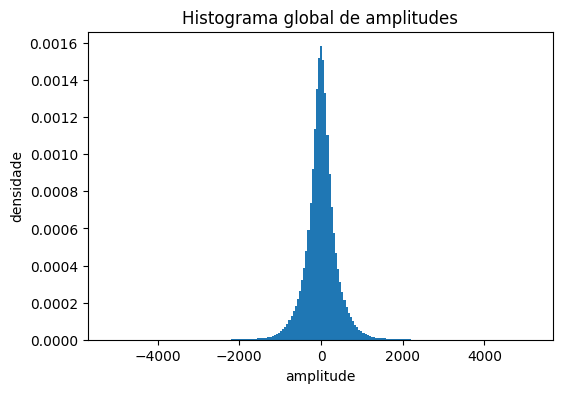

In [15]:
vals = vol[finite].ravel()
plt.figure(figsize=(6,4))
plt.hist(vals, bins=200, density=True)
plt.title("Histograma global de amplitudes")
plt.xlabel("amplitude"); plt.ylabel("densidade")
plt.show()

# Sugestão de janela de visualização
p1, p99 = np.percentile(vals, [1, 99])
vmin, vmax = float(p1), float(p99)

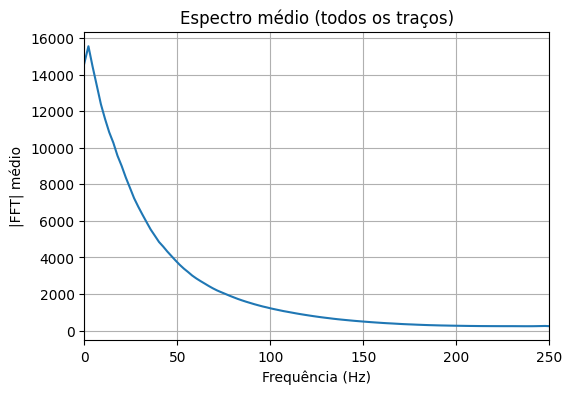

In [16]:
from scipy.fft import rfft, rfftfreq

I,X,Z = vol.shape
dt = 0.002  # exemplo: 2 ms; troque pelo seu sample interval
freq = rfftfreq(Z, dt)

# espectro médio (magnitude) sobre todos os traços
spec = np.abs(rfft(vol, axis=2)).mean(axis=(0,1))

plt.figure(figsize=(6,4))
plt.plot(freq, spec)
plt.xlabel("Frequência (Hz)"); plt.ylabel("|FFT| médio")
plt.title("Espectro médio (todos os traços)")
plt.xlim(0, freq.max()); plt.grid(True); plt.show()
